# Prediction-Interpretation Correlation

Actual NexLeth/SL-MERK pair explanations only. This notebook can resume the actual-pair LLM pipeline, then studies how SLformer prediction score relates to interpretation metrics.

Identify the project root once and import the same actual-pair batch utilities used by the pair-evaluation notebook.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "SAE").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from SAE.LLM_pipeline.utils.sl_merk_batch import (
    load_sae_artifacts,
    load_sl_merk_ground_truth,
    metric_record,
    prepare_pair_geometry,
    run_final_interpretation,
    run_pair_feature_explanations,
    run_name_from_model_config,
    sl_merk_rows_from_artifact,
    score_final_text,
    strategy_api_call_estimate,
)
from SAE.manifold.utils.projection import encode_dataset
from SAE.SAE_training.model import SAEConfig
from prompt_api.client import AigcBestChatClient

print("Project root:", PROJECT_ROOT)

/home/guoyu/SLformer_interpretation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/guoyu/SLformer_interpretation


Configure the actual-pair run. `RUN_LLM=False` keeps this notebook analysis-only; set it to `True` only when intentionally resuming missing actual explanations.

In [2]:
RUN_LLM = False
N_TARGETS = None
MIN_TARGET_SCORE = 0.5
RESUME_COMPLETED = True
SLEEP_BETWEEN_FEATURE_CALLS_S = 0.0

TRAIN_CONFIG_PATH = PROJECT_ROOT / "src" / "SAE" / "SAE_training" / "config" / "train_config.yaml"
MANIFOLD_CONFIG_PATH = PROJECT_ROOT / "src" / "SAE" / "manifold" / "config" / "manifold_config.yaml"
NOTEBOOK_CONFIG_PATH = PROJECT_ROOT / "src" / "SAE" / "LLM_pipeline" / "config" / "explainer_simulator_config.yaml"
SL_MERK_CSV = Path("/data/guoyu/KG-LLM-XSL/data/SL_MERK_groundtruth.csv")
CLIENT_CONFIG = SRC_ROOT / "prompt_api" / "client_config.yaml"
HF_MODEL_ROOT = Path("/data/guoyu/HF-models")

train_cfg = yaml.safe_load(TRAIN_CONFIG_PATH.read_text(encoding="utf-8"))
manifold_cfg = yaml.safe_load(MANIFOLD_CONFIG_PATH.read_text(encoding="utf-8"))
notebook_cfg = yaml.safe_load(NOTEBOOK_CONFIG_PATH.read_text(encoding="utf-8"))

feature_cfg = notebook_cfg["feature_selection"]
evidence_cfg = notebook_cfg["evidence"]
strategy_cfg = notebook_cfg["llm_strategy"]
metric_cfg = {
    "feature_embed_model_path": HF_MODEL_ROOT / "MedCPT-Query-Encoder",
    "feature_tokencls_model_path": HF_MODEL_ROOT / "keyphrase-extraction-kbir-inspec",
    "nli_model_path": HF_MODEL_ROOT / "PubMedBERT-MNLI-MedNLI",
    "evidence_embed_model_path": HF_MODEL_ROOT / "all-MiniLM-L6-v2",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "feature_candidate_backend": "token_cls",
}

run_name = run_name_from_model_config(SAEConfig(**dict(train_cfg["model"])))
SAE_DIR = Path(train_cfg["paths"]["output_base_dir"]) / train_cfg["paths"]["slformer_output_subdir"] / str(train_cfg["scope"]["cancer"]) / run_name
EXPLANATIONS_DIR = SAE_DIR / "explanations"
QUALIFIED_PAIRS_CSV = EXPLANATIONS_DIR / "sl_merk_qualified_pairs.csv"
client = AigcBestChatClient(config_path=CLIENT_CONFIG) if RUN_LLM else None

print("SAE dir:", SAE_DIR)
print("Explanations dir:", EXPLANATIONS_DIR)
print("RUN_LLM:", RUN_LLM)
print("Metric device:", metric_cfg["device"])

SAE dir: /home/guoyu/SLformer_interpretation/output/SAE/slformer/mix/hidden4096_gate0.5_orth1_k64
Explanations dir: /home/guoyu/SLformer_interpretation/output/SAE/slformer/mix/hidden4096_gate0.5_orth1_k64/explanations
RUN_LLM: False
Metric device: cuda


When `RUN_LLM=True`, select positive ground-truth pairs present in the aligned SLformer artifact. In analysis-only mode, skip model/data loading and read completed actual metrics directly.

In [3]:
if RUN_LLM:
    artifacts = load_sae_artifacts(PROJECT_ROOT, TRAIN_CONFIG_PATH, SAE_DIR)
    sae = artifacts["sae"]
    Xn = artifacts["Xn"]
    y = artifacts["y"]
    meta = artifacts["meta"]
    sl_merk = load_sl_merk_ground_truth(SL_MERK_CSV)
    target_rows = sl_merk_rows_from_artifact(sl_merk, meta, EXPLANATIONS_DIR)
    target_rows = target_rows.loc[target_rows["target_score"] >= float(MIN_TARGET_SCORE)].copy().reset_index(drop=True)
    if N_TARGETS is not None:
        target_rows = target_rows.head(int(N_TARGETS)).copy()
    QUALIFIED_PAIRS_CSV.parent.mkdir(parents=True, exist_ok=True)
    target_rows.to_csv(QUALIFIED_PAIRS_CSV, index=False)
    print("Qualified target rows:", len(target_rows))
    display(target_rows[["cancer", "gene_a", "gene_b", "target_idx", "target_score", "ground_truth_features"]])
else:
    print("RUN_LLM=False; skipping SAE artifact and target-row loading.")


RUN_LLM=False; skipping SAE artifact and target-row loading.


For actual-pair generation, encode the normalized embedding matrix once: $Z=f_{SAE}(X_n)$, shape `(n_samples, d_hidden)`.

In [4]:
if RUN_LLM:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    sae = sae.to(DEVICE)
    Z = encode_dataset(sae, Xn, batch_size=int(notebook_cfg["runtime"]["encode_batch_size"]), device=DEVICE)
    print("Device:", DEVICE)
    print("Xn shape:", Xn.shape)
    print("Z shape:", Z.shape)
else:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print("RUN_LLM=False; skipping SAE encoding.")


RUN_LLM=False; skipping SAE encoding.


Estimate the actual-pair LLM work. This is skipped unless `RUN_LLM=True`.

In [5]:
if RUN_LLM:
    estimate = strategy_api_call_estimate(
        client,
        str(strategy_cfg["feature_explainer"]),
        str(strategy_cfg["final_interpretation"]),
        int(feature_cfg["n_features_to_explain"]),
    )
    missing = sum(not (EXPLANATIONS_DIR / f"{row.cancer}_{row.gene_a}-{row.gene_b}" / "llm_evaluation_metrics.csv").exists() for row in target_rows.itertuples(index=False))
    print("Actual targets:", len(target_rows))
    print("Missing actual metric rows:", missing)
    print("API calls per missing target:", estimate)
    print("Total planned API calls without resume:", estimate["total_calls"] * missing)
else:
    print("RUN_LLM=False; loading completed actual metrics only.")

RUN_LLM=False; loading completed actual metrics only.


For actual pairs, compute local SAE geometry, generate atom explanations and final text, then score the mechanism section. No random/zero controls are generated here.

In [6]:
template = (PROJECT_ROOT / "src" / "SAE" / "doc" / "prompts" / "final_interpretation_prompt_template.txt").read_text(encoding="utf-8")
projection_cfg = manifold_cfg["projection"]

if not RUN_LLM:
    print("RUN_LLM=False; skipping actual-pair LLM generation.")
else:
    for target_pos in tqdm(range(len(target_rows)), desc="Actual pair explanations", unit="pair"):
        row = pd.Series(target_rows.iloc[target_pos])
        output_dir = EXPLANATIONS_DIR / f"{row['cancer']}_{row['gene_a']}-{row['gene_b']}"
        output_dir.mkdir(parents=True, exist_ok=True)
        metrics_path = output_dir / "llm_evaluation_metrics.csv"
        if RESUME_COMPLETED and metrics_path.exists():
            print(f"[metrics] actual {output_dir.name} reused")
            continue

        geometry = prepare_pair_geometry(
            sae=sae,
            Xn=Xn,
            y=y,
            meta=meta,
            Z=Z,
            target_idx=int(row["target_idx"]),
            projection_cfg=projection_cfg,
            device=DEVICE,
            feature_topk=int(projection_cfg["topk_features"]),
            sample_scope=str(evidence_cfg["sample_scope"]),
            top_m=int(evidence_cfg["top_m"]),
            explain_exemplars=int(evidence_cfg["explain_exemplars"]),
        )
        feature_rank = geometry["feature_rank"]
        interpretations = run_pair_feature_explanations(
            client=client,
            output_dir=output_dir,
            row=row,
            feature_rank=feature_rank,
            explain_indices=geometry["explain_indices"],
            Z=Z,
            y=y,
            meta=meta,
            feature_strategy=str(strategy_cfg["feature_explainer"]),
            n_features=int(feature_cfg["n_features_to_explain"]),
            sample_scope=str(evidence_cfg["sample_scope"]),
            state=geometry["state"],
            evidence_cfg=evidence_cfg,
            resume_completed=RESUME_COMPLETED,
            sleep_s=SLEEP_BETWEEN_FEATURE_CALLS_S,
        )
        final_result = run_final_interpretation(
            client=client,
            output_dir=output_dir,
            row=row,
            feature_rank=feature_rank,
            interpretations=interpretations,
            template=template,
            final_strategy=str(strategy_cfg["final_interpretation"]),
            resume_completed=RESUME_COMPLETED,
        )
        final_prompt = (output_dir / "final_prompt" / "final_interpretation_prompt.md").read_text(encoding="utf-8")
        metrics = score_final_text(row=row, final_text=final_result["text"], final_prompt=final_prompt, metric_cfg=metric_cfg)
        record = metric_record(row, output_dir, metrics, final_result)
        record["embedding_condition"] = "actual"
        pd.DataFrame([record]).to_csv(metrics_path, index=False)
        display(pd.DataFrame([record]))

RUN_LLM=False; skipping actual-pair LLM generation.


Load actual explanation metrics and correlate them with the SLformer prediction score.

In [7]:
metric_cols = ["feature_recall", "faithfulness_score", "hallucination_score"]
metric_labels = {
    "feature_recall": "Feature recall",
    "faithfulness_score": "Faithfulness",
    "hallucination_score": "Hallucination",
}
metric_files = sorted(EXPLANATIONS_DIR.glob("*_*/llm_evaluation_metrics.csv"))
results = pd.concat([pd.read_csv(path) for path in metric_files], ignore_index=True)
results["embedding_condition"] = "actual"
results = results[["pair", "cancer", "target_score", *metric_cols, "embedding_condition"]].copy()
print("Actual metric files:", len(metric_files))
display(results.sort_values("target_score", ascending=False))
correlation_table = pd.DataFrame(
    [{"metric": metric_labels[metric], "pearson_r": float(results["target_score"].corr(results[metric]))} for metric in metric_cols]
).round(3)
display(correlation_table)

Actual metric files:

 6


,pair,cancer,target_score,feature_recall,faithfulness_score,hallucination_score,embedding_condition
3,KRAS-PLK1,LUAD,0.943691,0.942489,0.860722,0.139278,actual
0,BRCA2-EZH2,BRCA,0.922231,0.950000,0.913764,0.086236,actual
4,KRAS-PSMB5,LUAD,0.896639,0.899902,0.845537,0.154463,actual
1,KRAS-ERH,LUAD,0.852795,0.178375,0.808364,0.191636,actual
2,KRAS-GATA2,LUAD,0.852047,0.868129,0.861754,0.138246,actual
5,KRAS-THOC1,LUAD,0.564279,0.950000,0.798510,0.201490,actual


,metric,pearson_r
0,Feature recall,-0.074
1,Faithfulness,0.685
2,Hallucination,-0.685


Plot actual-pair score-metric associations as raw points. Each point is one pair-cancer target.

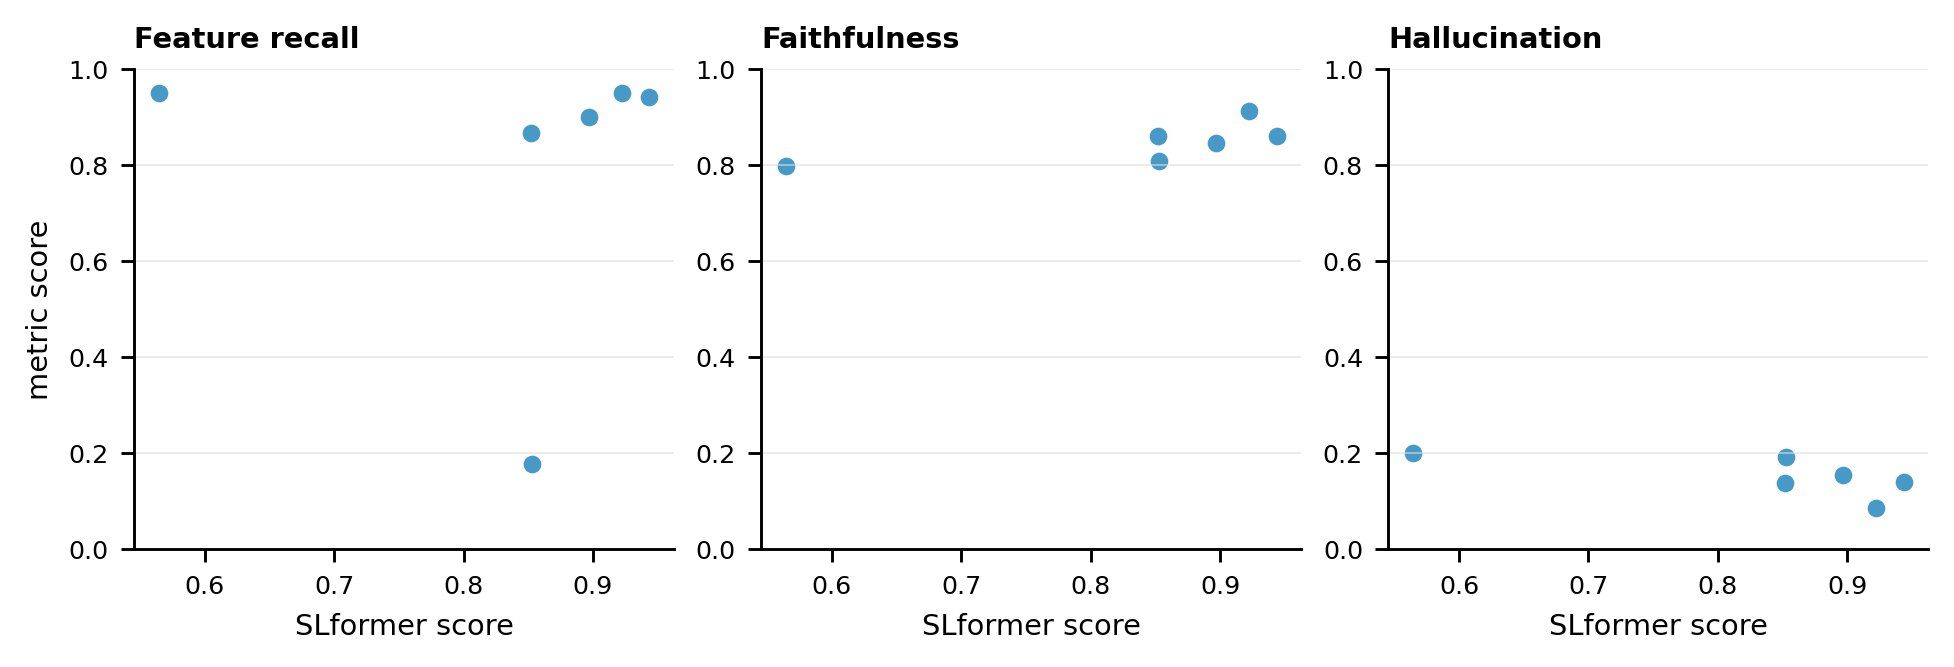

In [8]:
PAPER_BLUE = "#0072B2"
PAPER_GRAY = "#666666"

previous_rcparams = plt.rcParams.copy()
plt.rcParams.update({
    "figure.dpi": 260,
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

fig, axes = plt.subplots(1, len(metric_cols), figsize=(7.4, 2.45), constrained_layout=True, sharex=True)
for ax, metric in zip(axes, metric_cols):
    ax.scatter(results["target_score"], results[metric], s=24, color=PAPER_BLUE, alpha=0.72, linewidth=0)
    ax.set_title(metric_labels[metric], loc="left", fontweight="bold")
    ax.set_xlabel("SLformer score")
    ax.set_ylim(0, 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.45, alpha=0.7)
axes[0].set_ylabel("metric score")
plt.show()

plt.rcParams.update(previous_rcparams)